# Daily Challenge — US Superstore Data Visualization

Goals:
- Advanced data visualization techniques
- Interactive charts with Matplotlib / Plotly
- Elegant static presentation with Seaborn

Dataset: the classic **US Superstore** orders dataset (`superstore.csv`).

## 1. Data Preparation

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Consistent visual style
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

# Load the US Superstore data
df = pd.read_csv("superstore.csv", encoding="latin-1")

print("Shape:", df.shape)
df.head()

Shape: (9994, 21)


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [2]:
# Explore structure, dtypes and missing values
df.info()
print("\nMissing values per column:")
print(df.isnull().sum())

<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   str    
 2   Order Date     9994 non-null   str    
 3   Ship Date      9994 non-null   str    
 4   Ship Mode      9994 non-null   str    
 5   Customer ID    9994 non-null   str    
 6   Customer Name  9994 non-null   str    
 7   Segment        9994 non-null   str    
 8   Country        9994 non-null   str    
 9   City           9994 non-null   str    
 10  State          9994 non-null   str    
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   str    
 13  Product ID     9994 non-null   str    
 14  Category       9994 non-null   str    
 15  Sub-Category   9994 non-null   str    
 16  Product Name   9994 non-null   str    
 17  Sales          9994 non-null   float64
 18  Quantity       9994

In [3]:
# Basic cleaning & preprocessing

# 1) Parse the date columns (format is M/D/YYYY)
df["Order Date"] = pd.to_datetime(df["Order Date"], format="%m/%d/%Y")
df["Ship Date"] = pd.to_datetime(df["Ship Date"], format="%m/%d/%Y")

# 2) Drop exact duplicate rows, if any
before = len(df)
df = df.drop_duplicates()
print(f"Removed {before - len(df)} duplicate rows")

# 3) Derive convenient time columns from the order date
df["Year"] = df["Order Date"].dt.year
df["Month"] = df["Order Date"].dt.to_period("M").dt.to_timestamp()

# 4) Quick sanity check on the key numeric columns
df[["Sales", "Quantity", "Discount", "Profit"]].describe()

Removed 0 duplicate rows


,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000
mean,229.858001,3.789574,0.156203,28.656896
std,623.245101,2.225110,0.206452,234.260108
min,0.444000,1.000000,0.000000,-6599.978000
25%,17.280000,2.000000,0.000000,1.728750
50%,54.490000,3.000000,0.200000,8.666500
75%,209.940000,5.000000,0.200000,29.364000
max,22638.480000,14.000000,0.800000,8399.976000


## 2. Data Visualization with Matplotlib (interactive)

Matplotlib produces excellent static figures; for true interactivity (hover, zoom, pan) we pair it with **Plotly**, which the challenge also imports.

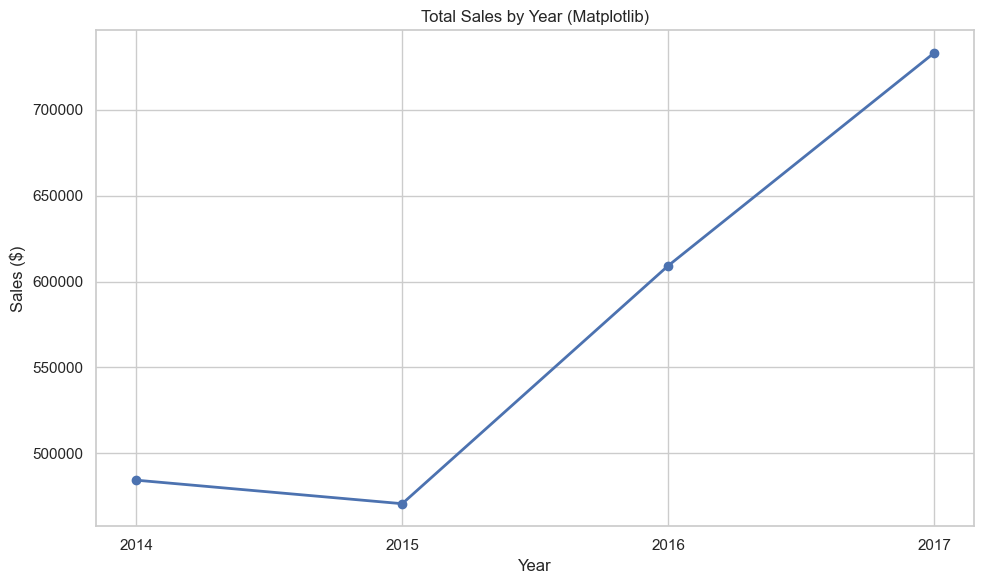

In [4]:
# --- Sales trend over the years ---

# Aggregate total sales per year
sales_by_year = df.groupby("Year")["Sales"].sum().reset_index()

# Static Matplotlib line chart
plt.figure()
plt.plot(sales_by_year["Year"], sales_by_year["Sales"], marker="o", linewidth=2)
plt.title("Total Sales by Year (Matplotlib)")
plt.xlabel("Year")
plt.ylabel("Sales ($)")
plt.xticks(sales_by_year["Year"])
plt.tight_layout()
plt.show()

In [5]:
# Interactive version of the same trend with Plotly (hover to read exact values)
# A monthly resolution makes the trend and seasonality easier to explore.
sales_by_month = df.groupby("Month")["Sales"].sum().reset_index()

fig = px.line(
    sales_by_month,
    x="Month",
    y="Sales",
    title="Monthly Sales Trend (interactive)",
    markers=True,
)
fig.update_layout(yaxis_title="Sales ($)")
fig.show()

In [6]:
# --- Interactive map of sales distribution ---
# The dataset contains a single country (United States), so a country-level map
# would show just one shape. A US state-level choropleth is far more informative.

print("Countries in data:", df["Country"].unique())

# Map full state names to their 2-letter codes (required by Plotly's USA-states scope)
state_abbrev = {
    "Alabama": "AL", "Alaska": "AK", "Arizona": "AZ", "Arkansas": "AR",
    "California": "CA", "Colorado": "CO", "Connecticut": "CT", "Delaware": "DE",
    "District of Columbia": "DC", "Florida": "FL", "Georgia": "GA", "Hawaii": "HI",
    "Idaho": "ID", "Illinois": "IL", "Indiana": "IN", "Iowa": "IA",
    "Kansas": "KS", "Kentucky": "KY", "Louisiana": "LA", "Maine": "ME",
    "Maryland": "MD", "Massachusetts": "MA", "Michigan": "MI", "Minnesota": "MN",
    "Mississippi": "MS", "Missouri": "MO", "Montana": "MT", "Nebraska": "NE",
    "Nevada": "NV", "New Hampshire": "NH", "New Jersey": "NJ", "New Mexico": "NM",
    "New York": "NY", "North Carolina": "NC", "North Dakota": "ND", "Ohio": "OH",
    "Oklahoma": "OK", "Oregon": "OR", "Pennsylvania": "PA", "Rhode Island": "RI",
    "South Carolina": "SC", "South Dakota": "SD", "Tennessee": "TN", "Texas": "TX",
    "Utah": "UT", "Vermont": "VT", "Virginia": "VA", "Washington": "WA",
    "West Virginia": "WV", "Wisconsin": "WI", "Wyoming": "WY",
}

sales_by_state = df.groupby("State")["Sales"].sum().reset_index()
sales_by_state["Code"] = sales_by_state["State"].map(state_abbrev)

fig = px.choropleth(
    sales_by_state,
    locations="Code",
    locationmode="USA-states",
    color="Sales",
    scope="usa",
    hover_name="State",
    color_continuous_scale="Blues",
    title="Sales Distribution by US State (interactive)",
)
fig.show()

Countries in data: <StringArray>
['United States']
Length: 1, dtype: str


## 3. Data Visualization with Seaborn (static)

/var/folders/19/hgbcmn617pq67g3xhjzlxc2r0000gn/T/ipykernel_8047/358754678.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top10, x="Sales", y="Product Name", palette="viridis")


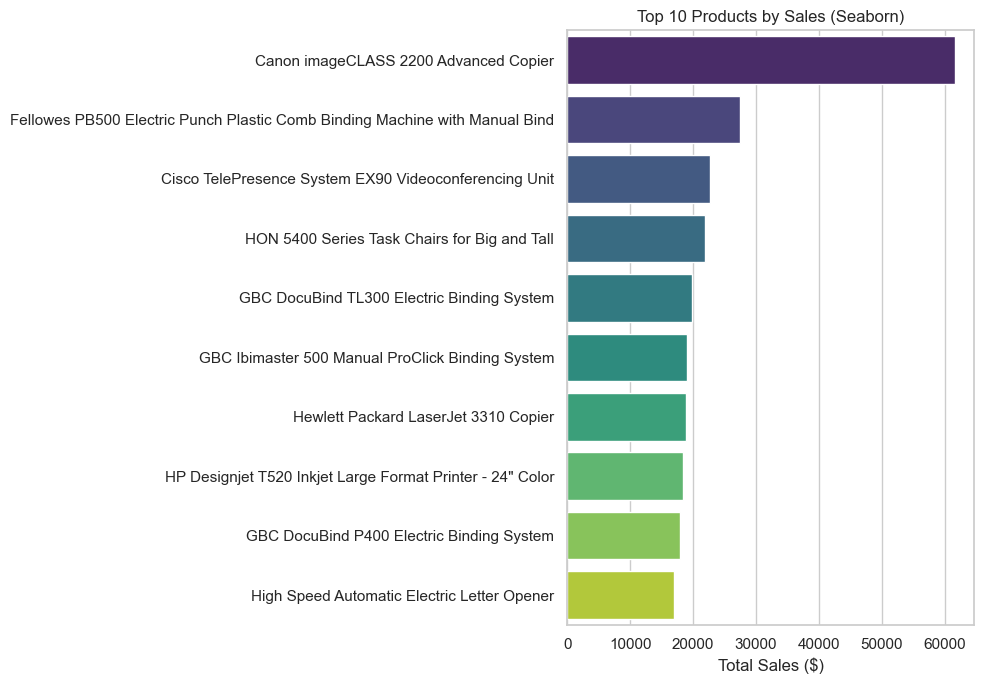

In [7]:
# --- Top 10 products by sales ---
top10 = (
    df.groupby("Product Name")["Sales"].sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

plt.figure(figsize=(10, 7))
sns.barplot(data=top10, x="Sales", y="Product Name", palette="viridis")
plt.title("Top 10 Products by Sales (Seaborn)")
plt.xlabel("Total Sales ($)")
plt.ylabel("")
plt.tight_layout()
plt.show()

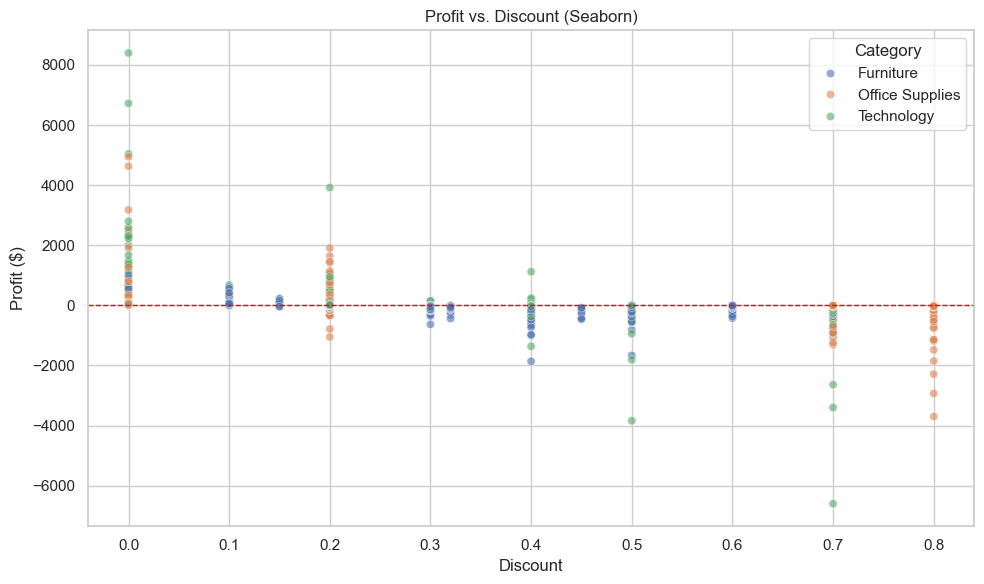

In [9]:
# --- Relationship between profit and discount ---
plt.figure()
sns.scatterplot(
    data=df,
    x="Discount",
    y="Profit",
    hue="Category",
    alpha=0.6,
)
plt.axhline(0, color="red", linestyle="--", linewidth=1)  # break-even line
plt.title("Profit vs. Discount (Seaborn)")
plt.xlabel("Discount")
plt.ylabel("Profit ($)")
plt.tight_layout()
plt.show()

## 4. Comparative Analysis & Insights

### Insights from the data
- **Sales trend:** total sales grow year over year, with a strong recurring spike toward the end of each year (Q4 / holiday season) visible in the monthly Plotly chart.
- **Geography:** sales are heavily concentrated in a few states — California and New York dominate, with Texas also large — while many central/mountain states contribute very little.
- **Top products:** revenue is driven by a handful of high-ticket items (copiers, binding machines, large tables/chairs); the top 10 are a tiny fraction of the catalogue yet a big share of sales.
- **Profit vs. discount:** there is a clear negative relationship. Orders with discounts above ~0.3 are frequently **unprofitable** (points below the red break-even line), and deep discounts (0.5+) almost always lose money. Discounting is eroding margins rather than boosting net profit.

### Matplotlib / Plotly vs. Seaborn
| Aspect | Matplotlib + Plotly | Seaborn |
| --- | --- | --- |
| Ease of use | More verbose; full manual control | Concise, sensible defaults for statistical plots |
| Interactivity | Plotly gives hover/zoom/pan and maps out of the box | Static only |
| Styling | Manual, highly customizable | Beautiful defaults, themes, palettes |
| Best for | Custom dashboards, geographic maps, exploration | Quick, polished statistical charts (bars, scatter, distributions) |

**Conclusion:** Seaborn is the fastest way to a clean, publication-ready static chart (the bar and scatter plots needed one line each). Plotly is the better choice when stakeholders need to *explore* the data themselves — the interactive line chart and the state choropleth let you read exact values and spot regional patterns that a static figure hides.